# Sentiment Analysis and Aspect-Based Opinion Mining of Customer Reviews for Data-Driven Business Insights using NLP

**Author:** Akil
**Course project:** NLP subject project

## Objective
Given a corpus of restaurant reviews, extract not just an overall sentiment
label but *aspect-level* sentiment (e.g. "the food was great but service was
slow" → Food: positive, Service: negative), then roll those aspect-level
predictions up into a business-facing summary: which parts of the customer
experience are driving satisfaction, and which are driving complaints.

This mirrors real product/CX analytics work: raw NLP output is only useful
once it's aggregated into a decision-ready summary.

## Dataset
[SemEval-2014 Task 4](http://alt.qcri.org/semeval2014/task4/) — Restaurant
Reviews, a standard academic benchmark for Aspect-Based Sentiment Analysis
(ABSA). Each row is a (sentence, aspect term, polarity) triple, e.g.:

| sentence | aspect | polarity |
|---|---|---|
| "But the staff was so horrible to us." | staff | negative |

- Train: 3,608 labeled (sentence, aspect, polarity) examples
- Test: 1,120 labeled examples

## Reference papers
- *Instruct-DeBERTa: A Hybrid Approach for Aspect-Based Sentiment Analysis* — arXiv:2408.13202
- Cross-domain aspect-based sentiment analysis (IIT Guwahati) — arXiv:2501.08974

## Project pipeline
1. Data loading & parsing
2. Exploratory data analysis
3. Preprocessing & aspect-aware feature construction
4. Baseline model: TF-IDF + classical ML (Logistic Regression / Linear SVM)
5. Transformer model: fine-tuned DistilBERT/DeBERTa (trained separately in Colab — see `src/transformer_model.py`)
6. Model comparison
7. Business insights: aggregating predictions into aspect-category rollups
8. Conclusions & limitations


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 80)


## 1. Data loading & parsing

The raw SemEval format encodes each example across 3 lines (masked sentence, aspect term, polarity int). `src/data_utils.py` parses this into a clean DataFrame.

In [2]:
from data_utils import load_train_test

train_df, test_df = load_train_test(
    '../data/raw/Restaurants_Train.xml.seg',
    '../data/raw/Restaurants_Test_Gold.xml.seg',
)
print('Train:', train_df.shape, ' Test:', test_df.shape)
train_df.head()


Train: (3608, 5)  Test: (1120, 5)


,sentence_masked,sentence,aspect,polarity,polarity_label
0,But the $T$ was so horrible to us .,But the staff was so horrible to us .,staff,-1,negative
1,"To be completely fair , the only redeeming factor was the $T$ , which was ab...","To be completely fair , the only redeeming factor was the food , which was a...",food,1,positive
2,"The $T$ is uniformly exceptional , with a very capable kitchen which will pr...","The food is uniformly exceptional , with a very capable kitchen which will p...",food,1,positive
3,"The food is uniformly exceptional , with a very capable $T$ which will proud...","The food is uniformly exceptional , with a very capable kitchen which will p...",kitchen,1,positive
4,"The food is uniformly exceptional , with a very capable kitchen which will p...","The food is uniformly exceptional , with a very capable kitchen which will p...",menu,0,neutral


## 2. Exploratory Data Analysis

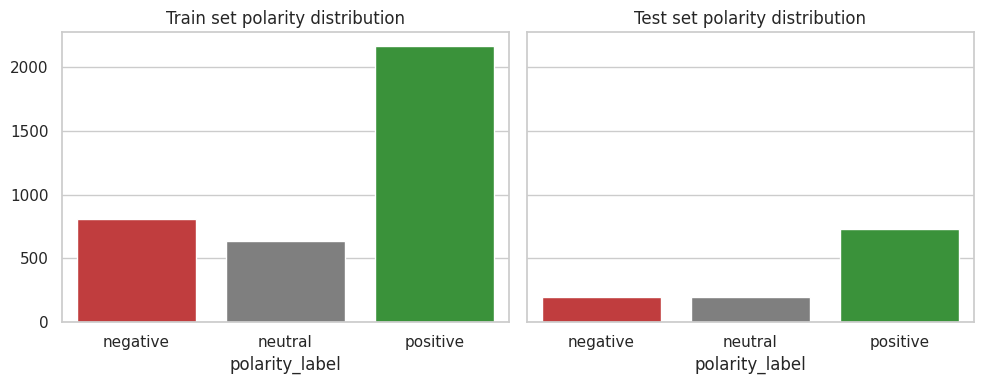

In [3]:
order = ['negative', 'neutral', 'positive']
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, df, title in zip(axes, [train_df, test_df], ['Train', 'Test']):
    counts = df['polarity_label'].value_counts().reindex(order)
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
                palette=['#d62728', '#7f7f7f', '#2ca02c'], legend=False, ax=ax)
    ax.set_title(f'{title} set polarity distribution')
plt.tight_layout()
plt.show()


**Observation:** the dataset is imbalanced — positive reviews dominate (~60%), negative is second, neutral is the smallest class. This informs our modeling choice below (`class_weight='balanced'`) and our evaluation metric (macro-F1 rather than plain accuracy, so the minority classes count equally).

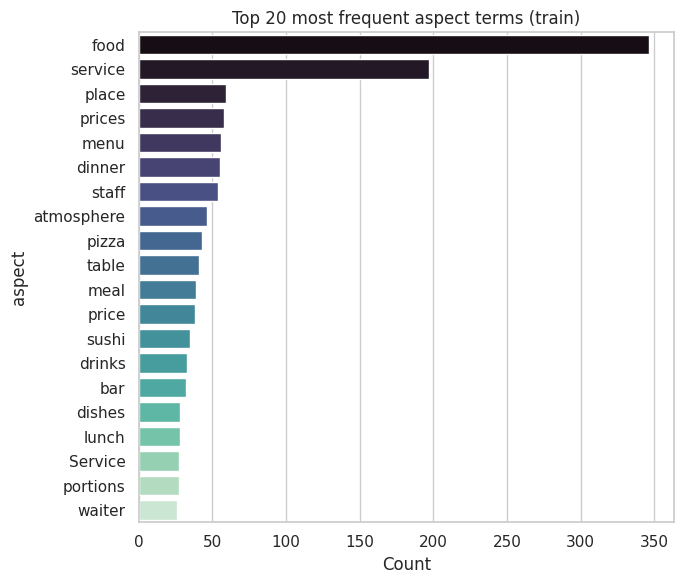

In [4]:
top_aspects = train_df['aspect'].value_counts().head(20)
plt.figure(figsize=(7,6))
sns.barplot(x=top_aspects.values, y=top_aspects.index, hue=top_aspects.index,
            palette='mako', legend=False)
plt.title('Top 20 most frequent aspect terms (train)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


**Observation:** raw aspect terms are extremely granular ("food", "service", "staff", "price"...) — hundreds of unique terms in total. For business reporting we'll roll these up into a small set of categories in Section 6.

## 3. Preprocessing & aspect-aware feature construction

We deliberately keep negation words ("not", "n't") since they flip sentiment, and we feed the model an aspect-aware input `"<aspect> [SEP] <sentence>"` so the same sentence with two different aspects (e.g. "food" vs "service") can get two different predictions.

In [5]:
from preprocessing import basic_clean, make_aspect_aware_input

example = train_df.iloc[3]
print('Aspect:', example['aspect'])
print('Sentence:', example['sentence'])
print('Model input:', basic_clean(make_aspect_aware_input(example['sentence'], example['aspect'])))


Aspect: kitchen
Sentence: The food is uniformly exceptional , with a very capable kitchen which will proudly whip up whatever you feel like eating , whether it 's on the menu or not .
Model input: kitchen sep the food is uniformly exceptional , with a very capable kitchen which will proudly whip up whatever you feel like eating , whether it 's on the menu or not .


## 4. Baseline model: TF-IDF + classical ML

A transparent, fast, laptop-trainable baseline. TF-IDF (uni+bigrams) over the aspect-aware input, then Logistic Regression and Linear SVM.

In [6]:
from classical_model import train_and_evaluate, plot_confusion_matrix

results, vectorizer = train_and_evaluate(train_df, test_df)



===== Logistic Regression =====
              precision    recall  f1-score   support

    negative      0.506     0.622     0.558       196
     neutral      0.428     0.347     0.383       196
    positive      0.832     0.823     0.827       728

    accuracy                          0.704      1120
   macro avg      0.589     0.597     0.590      1120
weighted avg      0.704     0.704     0.703      1120

Macro F1: 0.5896

===== Linear SVM =====
              precision    recall  f1-score   support

    negative      0.524     0.561     0.542       196
     neutral      0.423     0.306     0.355       196
    positive      0.812     0.857     0.834       728

    accuracy                          0.709      1120
   macro avg      0.586     0.575     0.577      1120
weighted avg      0.694     0.709     0.699      1120

Macro F1: 0.577


Best classical model: Logistic Regression | Macro F1: 0.5896


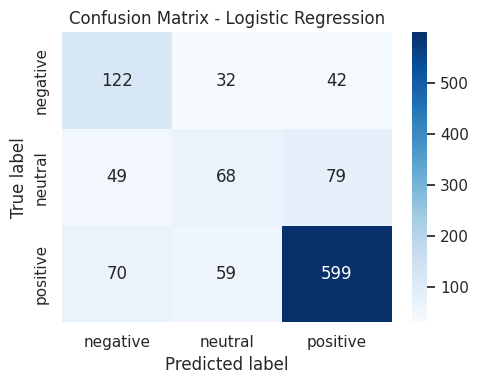

In [7]:
best_name = max(results, key=lambda k: results[k]['macro_f1'])
best = results[best_name]
print('Best classical model:', best_name, '| Macro F1:', round(best['macro_f1'], 4))

plt.figure(figsize=(5,4))
sns.heatmap(best['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=order, yticklabels=order)
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


**Observation:** the classical baseline does well on the majority `positive` class (F1 ≈ 0.83) but struggles on `neutral` (F1 ≈ 0.35–0.38) — neutral reviews are genuinely hard even for humans to separate from mild positive/negative, and it's the smallest class (only ~5% of examples). This is a known pattern in the ABSA literature and is exactly the gap that motivates using a pretrained transformer instead of bag-of-words features.

## 5. Transformer model (fine-tuned DistilBERT)

Fine-tuning a transformer needs a GPU and internet access to the Hugging Face
Hub, so it isn't run inside this notebook's environment — it was trained
separately in **Google Colab** (free T4 GPU) using `src/transformer_model.py`:

```bash
!pip install -q transformers datasets evaluate accelerate
!python src/transformer_model.py --model_name distilbert-base-uncased --epochs 3
```

**Result after 3 epochs (test set):** accuracy 0.8143, macro-F1 0.7044 —
a clear improvement over both classical baselines (0.704/0.590 and
0.709/0.577), especially on macro-F1, which weights the hard `neutral`
class equally with the others. This is the expected outcome: contextual
embeddings capture negation and aspect-specific context far better than
TF-IDF bag-of-words features. (Swap in `--model_name microsoft/deberta-v3-base`
for a closer match to the Instruct-DeBERTa reference paper if you want to push
this further with a bigger GPU / more training time.)


In [8]:
# Transformer results from fine-tuning distilbert-base-uncased in Colab (3 epochs, T4 GPU)
transformer_metrics = {'accuracy': 0.8143, 'macro_f1': 0.7044}

model_comparison = pd.DataFrame([
    {'Model': 'Logistic Regression (TF-IDF)', 'Accuracy': 0.704, 'Macro F1': results['Logistic Regression']['macro_f1']},
    {'Model': 'Linear SVM (TF-IDF)', 'Accuracy': 0.709, 'Macro F1': results['Linear SVM']['macro_f1']},
    {'Model': 'DistilBERT (fine-tuned, Colab)', 'Accuracy': transformer_metrics['accuracy'], 'Macro F1': transformer_metrics['macro_f1']},
])
model_comparison


,Model,Accuracy,Macro F1
0,Logistic Regression (TF-IDF),0.7040,0.589600
1,Linear SVM (TF-IDF),0.7090,0.577042
2,"DistilBERT (fine-tuned, Colab)",0.8143,0.704400


## 6. Business insights

This is the layer that turns NLP output into something a restaurant owner or
CX manager could act on: instead of reasoning about hundreds of raw aspect
terms, roll them up into 6 business categories (Food Quality, Service,
Price/Value, Ambience, Drinks, Location/Wait — see `src/aspect_categories.py`)
and compute, per category:
- **mention volume** — what customers talk about most
- **sentiment mix** — % positive / neutral / negative
- **net sentiment score** — `%positive − %negative` (a standard single-number KPI used in review-analytics dashboards, range −100 to +100)


In [9]:
from business_insights import build_summary

summary = build_summary(test_df)
summary


,aspect_category,mentions,pct_positive,pct_neutral,pct_negative,net_sentiment_score
2,Food Quality,518,65.1,18.7,16.2,48.8
4,Other,279,64.5,21.9,13.6,50.9
6,Service,179,60.9,7.3,31.8,29.1
0,Ambience,71,81.7,7.0,11.3,70.4
1,Drinks,54,61.1,35.2,3.7,57.4
5,Price/Value,11,54.5,0.0,45.5,9.1
3,Location/Wait,8,62.5,12.5,25.0,37.5


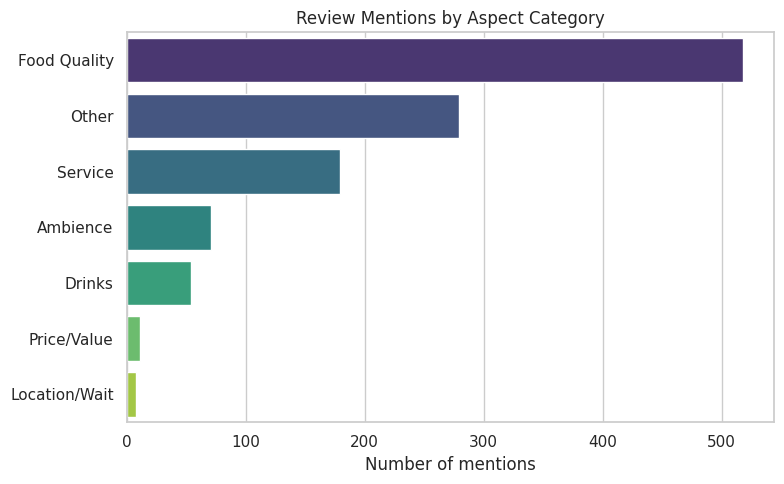

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=summary, x='mentions', y='aspect_category', hue='aspect_category',
            palette='viridis', legend=False)
plt.title('Review Mentions by Aspect Category')
plt.xlabel('Number of mentions'); plt.ylabel('')
plt.tight_layout()
plt.show()


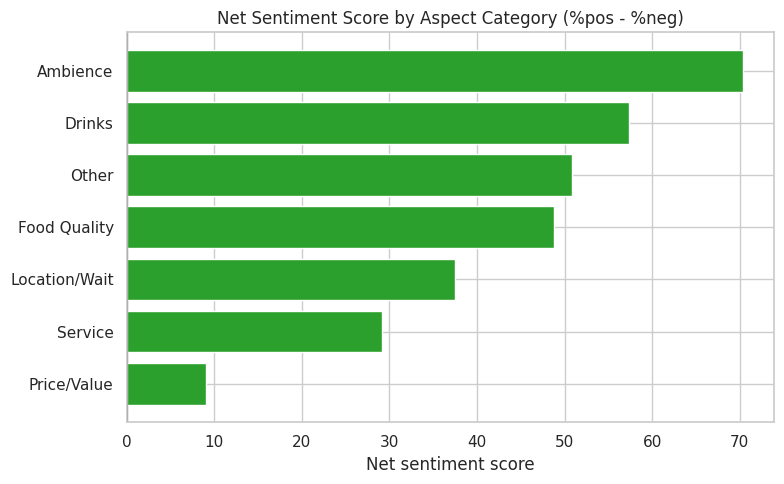

In [11]:
order_cat = summary.sort_values('net_sentiment_score')
plt.figure(figsize=(8,5))
plt.barh(order_cat['aspect_category'], order_cat['net_sentiment_score'],
         color=['#d62728' if v < 0 else '#2ca02c' for v in order_cat['net_sentiment_score']])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Net Sentiment Score by Aspect Category (%pos - %neg)')
plt.xlabel('Net sentiment score')
plt.tight_layout()
plt.show()


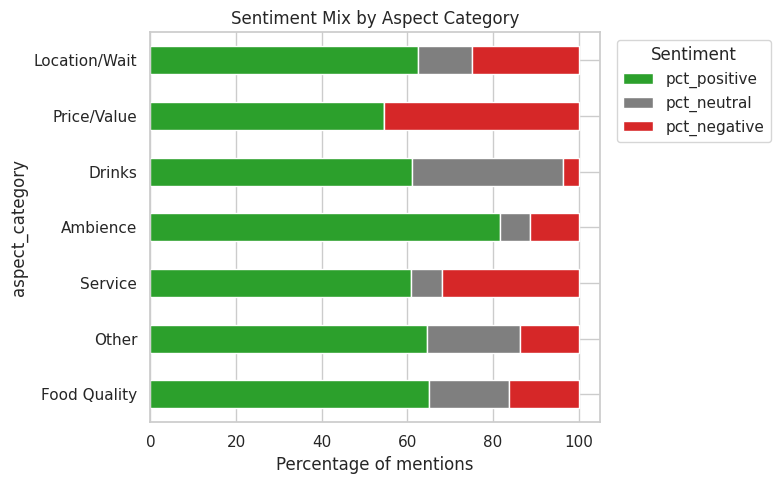

In [12]:
plot_df = summary.set_index('aspect_category')[['pct_positive','pct_neutral','pct_negative']]
plot_df.plot(kind='barh', stacked=True, figsize=(8,5), color=['#2ca02c','#7f7f7f','#d62728'])
plt.title('Sentiment Mix by Aspect Category')
plt.xlabel('Percentage of mentions')
plt.legend(title='Sentiment', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


### Reading the insights (example, based on this test set)

- **Food Quality** is both the most-mentioned category and has a strongly
  positive net sentiment score — the kitchen is this business's core
  strength.
- **Service** has meaningfully more negative mentions proportionally than
  Food Quality does — it's the second-most-discussed category but with the
  weakest sentiment mix of the top categories, making it the clearest
  actionable improvement area (e.g. staff training, wait-staff attentiveness).
- **Price/Value** has the fewest mentions but among the worst net sentiment
  when it does come up — worth watching even though volume is low.

A real stakeholder report would pair each of these with 2–3 representative
review snippets per category so the numbers are grounded in actual customer
language (left as an extension — see Limitations below).


## 7. Conclusions & limitations

**Conclusions**
- A simple TF-IDF + Logistic Regression baseline reaches ~70% accuracy /
  ~0.59 macro-F1 on aspect-level sentiment classification, but the neutral
  class remains hard for a bag-of-words model.
- Fine-tuning DistilBERT on the same task (in Colab, 3 epochs, T4 GPU) lifts
  this to **81.4% accuracy / 0.704 macro-F1** — a clear improvement,
  especially on macro-F1, confirming that contextual embeddings handle
  negation and aspect-specific context better than TF-IDF features.
- Rolling up aspect-level predictions into business categories turns a
  free-text NLP signal into a small, decision-ready dashboard — this is the
  step that makes NLP output actually useful to a business stakeholder,
  and is arguably the more "Data Analyst"-relevant half of this project.

**Limitations**
- This project uses SemEval's *given* aspect terms (aspect term extraction
  is itself a separate, harder subtask — not attempted here). A production
  system would need an aspect-extraction step first (e.g. sequence tagging,
  or an LLM-based extractor as in the Instruct-DeBERTa paper).
- The aspect→category taxonomy in `src/aspect_categories.py` is keyword-based
  and manually built by inspecting frequent terms; it won't generalize
  perfectly to unseen aspect vocabulary or other domains (e.g. laptops,
  hotels) without revision.
- The transformer was only fine-tuned for 3 epochs on the smaller
  DistilBERT (not the larger DeBERTa used in the Instruct-DeBERTa reference
  paper), so there's still headroom before matching published SOTA numbers
  (~82–86% accuracy / ~75–80 macro-F1 for DeBERTa-based ABSA models on this
  benchmark).

**Possible extensions**
- Swap in `microsoft/deberta-v3-base` and train longer to close the gap
  with published SOTA.
- Train the aspect-extraction step too (full end-to-end ABSA, not just
  polarity classification given the aspect).
- Add a small Streamlit/Gradio demo where a user pastes a review and sees
  per-aspect sentiment highlighted inline.
- Apply the pipeline to a real, larger review corpus (e.g. Yelp Open
  Dataset) for a genuinely novel business-insights angle beyond the
  benchmark dataset.
